# Review of Statistics

This notebook shows some basic statistics needed for this course.

The notebook uses the `Statistics` package (a standard library, built-in) for descriptive statistics (averages, autocorrelations, etc) and the [Distributions.jl](https://github.com/JuliaStats/Distributions.jl) package for statistical distributions (pdf, cdf, etc).

The the `DelimitedFiles` and `LinearAlgebra` (standard libraries) are used to read a csv file with data and some basic matrix manipulations.

## Load Packages and Extra Functions

In [1]:
using Printf, Statistics, DelimitedFiles, LinearAlgebra, Distributions

include("src/OlsGMNW.jl")
include("src/printmat.jl");

In [2]:
using Plots, LaTeXStrings             #packages for plotting and LaTeX
default(size = (480,320),fmt = :png)  #or :svg

# Distributions

## Probability Density Function (pdf)

The cells below calculate and plot pdfs and cdfs of some distributions often used in the lecture notes. The `Distributions.jl` package has many more distributions.

### A Remark on the Code

- Notice that the `Distributions.jl` package wants `Normal(μ,σ)`, where `σ` is the standard deviation. However, the notation in the lecture notes is $N(\mu,\sigma^2)$. For instance, $N(0,2)$ from the lectures is coded as `Normal(0,sqrt(2))`.
- `pdf.(Normal(0,1),x)` calculates the pdf of a standard normal variable at each value in the array `x`. Notice the dot (`.`).

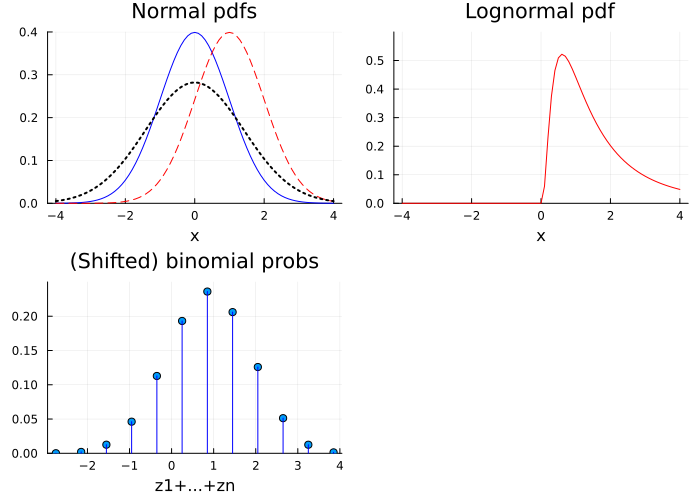

In [3]:
x  = -4:0.1:4
pdf1a  = pdf.(Normal(0,1),x)                     #Normal
pdf1b  = pdf.(Normal(1,1),x) 
pdf1c  = pdf.(Normal(0,sqrt(2)),x)        

pdf2  = pdf.(LogNormal(0.25,sqrt(0.75)),x)       #LogNormal

(n,p,a,b) = (11,0.55,0.35,-0.25)                 #Binomial
z  = 0:n
z2 = z*a + (n.-z)*b                                #shifted binomial, 1->a, 0->b
pdf3 = pdf.(Binomial(n,p),z)
  

p1 = plot( x,hcat(pdf1a,pdf1b,pdf1c),
           linecolor = [:blue :red :black],
           linestyle = [:solid :dash :dot],
           linewidth = [1 1 2],
           legend = nothing,
           ylims = (0,0.4),
           title = "Normal pdfs",
           xlabel = "x")

p2 = plot( x,pdf2,
           linecolor = :red,
           legend = nothing,
           ylims = (0,0.6),
           title = "Lognormal pdf",
           xlabel = "x")  

p3 = plot( z2,pdf3,
           linecolor = :blue,
           legend = nothing,
           seriestype=:stem, 
           marker=:circle,           
           ylims = (0,0.25),
           title = "(Shifted) binomial probs",
           xlabel = "z1+...+zn")             
  
pAll = plot( p1,p2,p3,                    #combine the subplots
             layout = @layout[a a;a _],
             size = (700,500) )
display(pAll)           


Pr(x<=0.5)      0.691


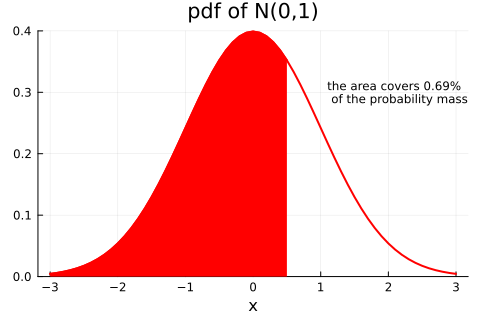

In [4]:
x  = -3:0.1:3
xb = x[x.<=0.5]                  #pick out x values <= 0.5

pdfx  = pdf.(Normal(0,1),x)       #calculate the pdf of a N(0,1) variable
pdfxb = pdf.(Normal(0,1),xb)      #colour the area below this curve
Prb = cdf(Normal(0,1),0.5)
printlnPs("Pr(x<=0.5) ",Prb)

p1 = plot( x,pdfx,                        #plot pdf
           linecolor = :red,
           linewidth = 2,
           legend = nothing,
           ylims = (0,0.4),
           title = "pdf of N(0,1)",
           xlabel = "x",
           annotation = (1.1,0.3,text("the area covers $(round(Prb,digits=2))%\n of the probability mass",:left,8)) )
plot!(xb,pdfxb,linecolor=:red,linewidth=2,legend=nothing,fill=(0,:red))    #plot area under pdf
display(p1)

In [5]:
printlnPs("5% quantile of N(0,1): ", quantile(Normal(0,1),0.05))

5% quantile of N(0,1):     -1.645


## Expected Values and Variances

The random variable used in the example below can only take two values in the vector `x = [x₁,x₂]`, with probabilities in `p = [p₁,1-p₁]`.   (`π` is already defined in one of the packages.)

We define a simple function `E(x,p)` to calculate an expectation.

In [6]:
"""
    E(x,p)

Calculate the expectation from vectors of outcomes and their probabilities.
"""
E(x,p) = sum(p.*x)     #or p'x

E

In [7]:
x = [9.5,11]
p = [0.4,0.6]               #probabilities

μ = E(x,p)     
printlnPs("μ: ",μ)

σ² =  E((x.-μ).^2,p)
printlnPs("σ²: ",σ²)

printlnPs("\nCheck the variance against the theoretical result:", p[1]*p[2]*(x[2]-x[1])^2)

       μ:     10.400
      σ²:      0.540

Check the variance against the theoretical result:     0.540


## Expected Value of a Function and Its Derivative

In [8]:
Elnx = E(log.(x),p)     #expected value of log(x)
println("log(x) and its expected value")
Edlnx = E(1.0./x,p)      #derivative of log(x) is 1/x

xut = hcat([x;μ],[log.(x);Elnx],[1.0./x;Edlnx])
printmat(xut;rowNames=["state 1","state 2","expected value"],colNames=["x","log(x)","dlog(x)/dx"],width=12)

log(x) and its expected value
                         x      log(x)  dlog(x)/dx
state 1              9.500       2.251       0.105
state 2             11.000       2.398       0.091
expected value      10.400       2.339       0.097



# Expected Value and Variance of Linear Combinations

In [9]:
μ = [11.5, 9.5, 6]/100          #expected returns for 3 assets
Σ = [166  34  58;               #covariance matrix
      34  64   4;
      58   4 100]/100^2
Rf = 0.03                       #riskfree return

0.03

In [10]:
w = [0.25,0.68,0.07]      #portfolio weights summing to 1

3-element Vector{Float64}:
 0.25
 0.68
 0.07

In [11]:
ERp = w'μ
VarRp = w'*Σ*w

xut = [ERp,VarRp,sqrt(VarRp)]
printmat(xut;rowNames=["mean","variance","std"])

mean         0.098
variance     0.005
std          0.074



# Linear Regressions

using the included function `OlsGM(Y,X)`

In [12]:
x = readdlm("Data/FFmFactorsPs.csv",',',skipstart=1)

                #yearmonth, market, small minus big, high minus low
(ym,Rme,RSMB,RHML) = (x[:,1],x[:,2]/100,x[:,3]/100,x[:,4]/100)
x = nothing

printlnPs("Sample size:",size(Rme))

Sample size:    (660,)


In [13]:
Y = Rme                    #T-vector, to get standard OLS notation
T = size(Y,1)              
X = [ones(T) RSMB RHML]    #TxK matrix, regressors

(b,_,_,V,R²) = OlsGM(Y,X)
Stdb = sqrt.(diag(V))        #standard errors, assuming iid errors, diag is from `LinearAlgebra`

printblue("OLS Results:\n")
xNames = ["c","SMB","HML"]
printmat(b,Stdb,colNames=["b","std"],rowNames=xNames)

printlnPs("R²: ",R²)

OLS Results:

            b       std
c       0.006     0.002
SMB     0.380     0.056
HML    -0.257     0.055

      R²:      0.108


## Test a Single Coefficient

Suppose we want to test if the 2nd coefficient os equal to 0.3 THis can be done as follows. 
If the |t-stat|, is larger than 1.645, then you cannot reject the null hypothesis on the 10% significance level

In [14]:
t = (b[2]-0.3)/Stdb[2]

printlnPs("|t| : ",abs(t))    
    

    |t| :      1.431
